# Python DA Assignment 2 - Data Visualization
**Dataset:** Seaborn `taxis` (NYC taxi trips, March 2019)
**Tools:** Pandas, Matplotlib, Seaborn

## 1. Load the dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load the 'taxis' dataset
df = sns.load_dataset("taxis")

print("Shape:", df.shape)
df.head()

Shape: (6433, 14)


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


## 2. Handle missing values

In [2]:
# Missing values per column
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing data:\n")
print(pd.DataFrame({"missing": missing, "pct": (missing / len(df) * 100).round(2)}))

Columns with missing data:

                 missing   pct
payment               44  0.68
pickup_zone           26  0.40
dropoff_zone          45  0.70
pickup_borough        26  0.40
dropoff_borough       45  0.70


All missing values are in **categorical** columns. The strategy per column:

| Column | Missing | Strategy | Reason |
|---|---|---|---|
| `payment` | 44 | Mode imputation | Categorical, small share; mode is a reasonable fill |
| `dropoff_zone`, `dropoff_borough` | 45 | Mode imputation | Not used as an analysis axis; mode keeps the rows |
| `pickup_zone`, `pickup_borough` | 26 | **Drop rows** | Central to the borough/zone analysis; a location cannot be reasonably guessed, and filling with the mode would inflate Manhattan |

In [3]:
df_clean = df.copy()

# Critical columns: drop rows with missing pickup location
df_clean = df_clean.dropna(subset=["pickup_zone", "pickup_borough"])

# Remaining categorical columns: impute with the mode
for col in ["payment", "dropoff_zone", "dropoff_borough"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

df_clean = df_clean.reset_index(drop=True)

print("Rows before:", len(df), "| Rows after:", len(df_clean))
print("Remaining missing values:", df_clean.isnull().sum().sum())

Rows before: 6433 | Rows after: 6407
Remaining missing values: 0


## 3. Visualizations using Matplotlib / Pandas plot

### 3.1 Line chart - fare over time

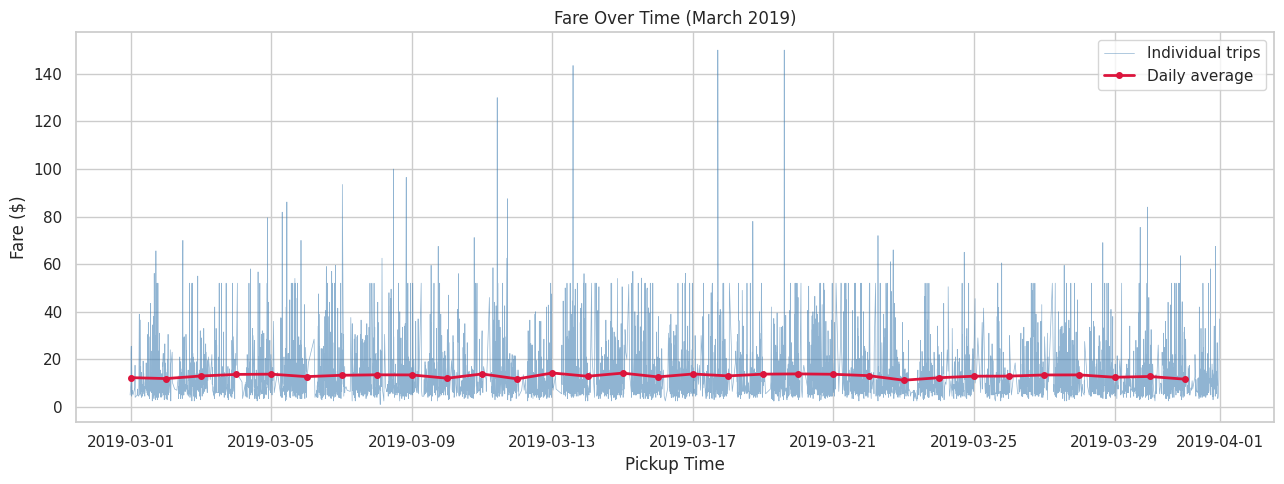

In [4]:
# Ensure pickup is datetime, then sort by time
df_clean["pickup"] = pd.to_datetime(df_clean["pickup"])
ts = df_clean.sort_values("pickup")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts["pickup"], ts["fare"], color="steelblue", linewidth=0.5, alpha=0.6, label="Individual trips")

# Daily average overlay to make the trend readable
grp = ts.set_index("pickup")["fare"].resample("D")
daily = grp.mean()[grp.count() >= 50]   # skip the single stray trip on 28 Feb
ax.plot(daily.index, daily.values, color="crimson", linewidth=2, marker="o", markersize=4, label="Daily average")

ax.set_title("Fare Over Time (March 2019)")
ax.set_xlabel("Pickup Time")
ax.set_ylabel("Fare ($)")
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** Individual fares vary widely, with a few trips above $100. The daily average stays in a narrow $12-$14 band with no upward or downward trend, and weekends run slightly lower than weekdays.

### 3.2 Bar chart - total fare by pickup borough

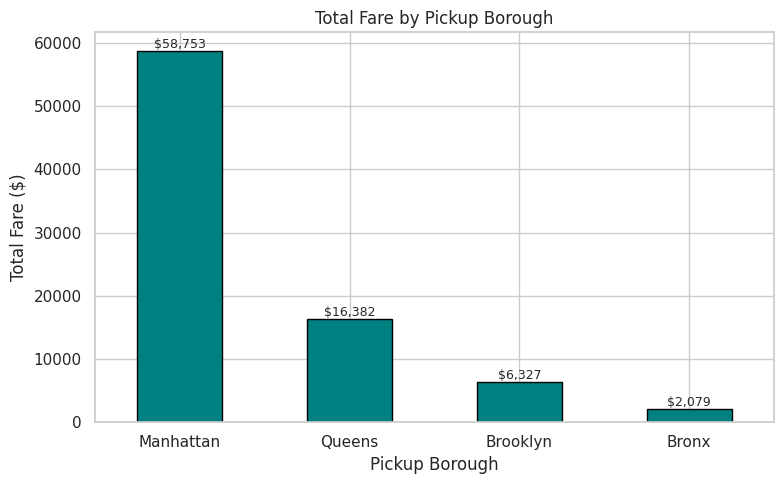

In [5]:
borough_fare = df_clean.groupby("pickup_borough")["fare"].sum().sort_values(ascending=False)

ax = borough_fare.plot(kind="bar", color="teal", figsize=(8, 5), edgecolor="black")
ax.set_title("Total Fare by Pickup Borough")
ax.set_xlabel("Pickup Borough")
ax.set_ylabel("Total Fare ($)")
plt.xticks(rotation=0)
for i, v in enumerate(borough_fare.values):
    ax.text(i, v, f"${v:,.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

**Insight:** Manhattan brings in about 70% of total fare. Queens contributes about 20% from only about 10% of trips, because its trips are much longer (average 7.5 miles vs 2.4 in Manhattan).

### 3.3 Pie chart - trips by payment method

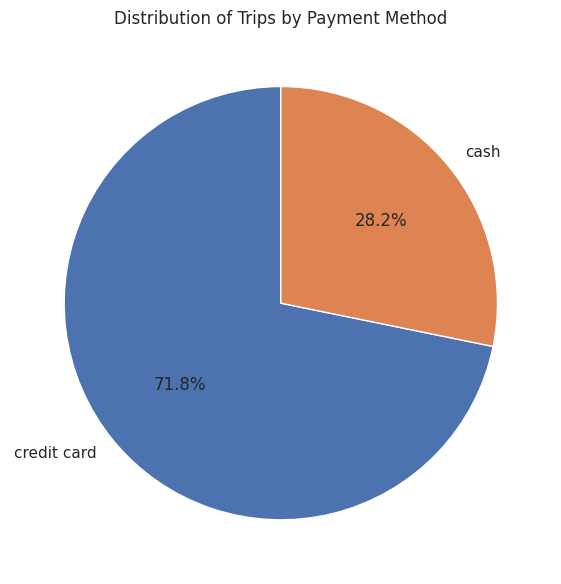

In [6]:
payment_counts = df_clean["payment"].value_counts()

payment_counts.plot(
    kind="pie", autopct="%1.1f%%", startangle=90,
    colors=["#4c72b0", "#dd8452"], figsize=(6, 6),
    wedgeprops={"edgecolor": "white"}
)
plt.title("Distribution of Trips by Payment Method")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Insight:** Credit card is the dominant payment method at about 72% of trips; the remaining 28% are cash.

### 3.4 Histogram - distribution of distance

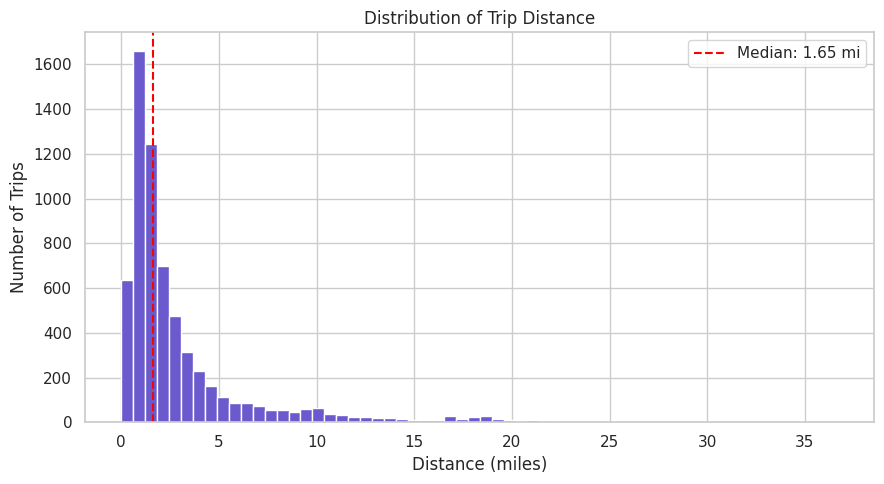

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df_clean["distance"], bins=60, color="slateblue", edgecolor="white")
ax.axvline(df_clean["distance"].median(), color="red", linestyle="--", label=f"Median: {df_clean['distance'].median():.2f} mi")
ax.set_title("Distribution of Trip Distance")
ax.set_xlabel("Distance (miles)")
ax.set_ylabel("Number of Trips")
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** The distribution is strongly right-skewed. The median trip is 1.65 miles and about 73% of trips are under 3 miles, with a long tail of rare trips beyond 20 miles.

### 3.5 Box plot - tip by pickup borough

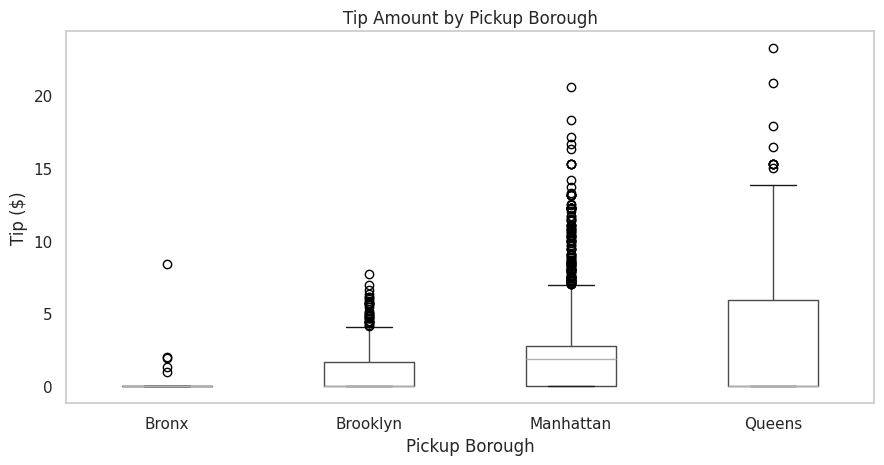

In [8]:
ax = df_clean.boxplot(column="tip", by="pickup_borough", figsize=(9, 5), grid=False)
plt.suptitle("")
plt.title("Tip Amount by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip ($)")
plt.tight_layout()
plt.show()

**Insight:** Manhattan has a median tip of about $1.86, while the median in the other three boroughs is $0. This is a data effect: cash trips record no tip (average cash tip is $0.00), so borough tip comparisons mostly reflect each borough's cash/card mix. Queens has the highest mean tip ($3.04) because of a few long, high-tip trips.

## 4. Visualizations using Seaborn

### 4.1 Count plot - trips per pickup borough

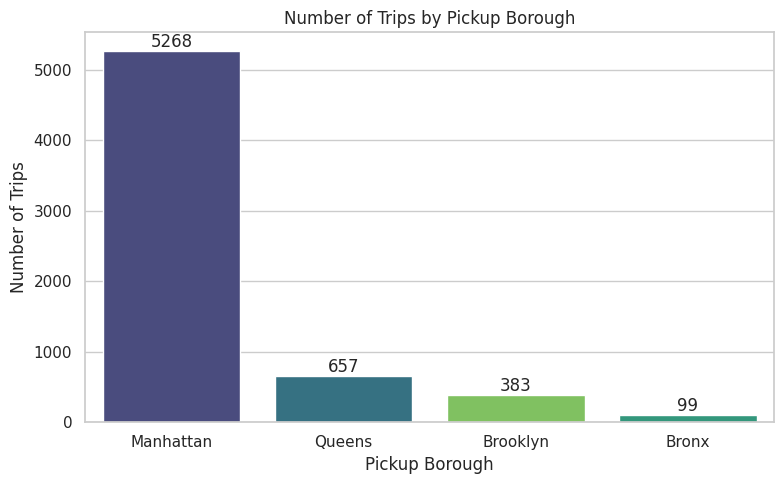

In [9]:
order = df_clean["pickup_borough"].value_counts().index

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_clean, x="pickup_borough", order=order, palette="viridis", hue="pickup_borough", legend=False)
ax.set_title("Number of Trips by Pickup Borough")
ax.set_xlabel("Pickup Borough")
ax.set_ylabel("Number of Trips")
for c in ax.containers:
    ax.bar_label(c)
plt.tight_layout()
plt.show()

**Insight:** About 82% of trips start in Manhattan, so the dataset is heavily Manhattan-centred and the other boroughs have small samples.

### 4.2 Scatter plot - distance vs fare, coloured by pickup borough

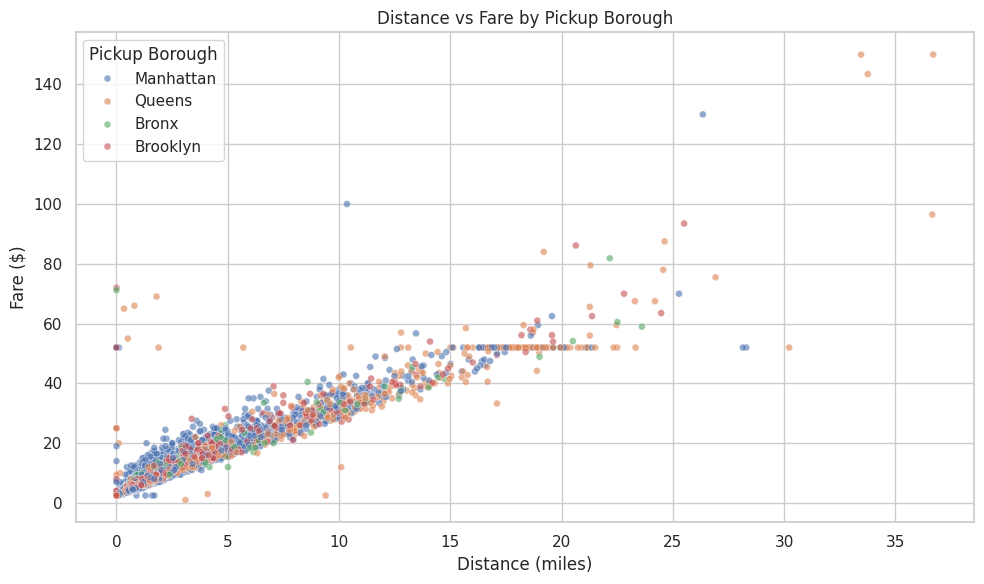

Correlation (distance, fare): 0.939


In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x="distance", y="fare", hue="pickup_borough", alpha=0.6, s=25)
plt.title("Distance vs Fare by Pickup Borough")
plt.xlabel("Distance (miles)")
plt.ylabel("Fare ($)")
plt.legend(title="Pickup Borough")
plt.tight_layout()
plt.show()

print("Correlation (distance, fare):", round(df_clean["distance"].corr(df_clean["fare"]), 3))

**Insight:** Fare rises almost linearly with distance (correlation about 0.94). Manhattan trips cluster at short distances. A flat horizontal band at $52 (consistent with the fixed airport fare) sits across 15-30 miles, and the longest, highest-fare trips (30+ miles, up to $150) start in Queens.

### 4.3 Heatmap - correlation of numerical variables

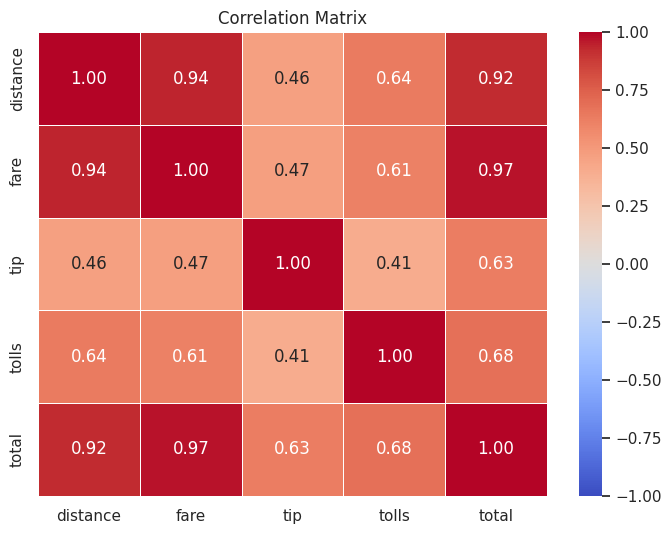

In [11]:
num_cols = ["distance", "fare", "tip", "tolls", "total"]
corr = df_clean[num_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

**Insight:** `fare` and `total` are almost perfectly correlated (0.97) and `distance` is strongly correlated with both (0.94 and 0.92). `tip` has the weakest links (0.41 to 0.63), largely because cash trips record zero tip.

### 4.4 Pair plot - distance, fare, tip, total by pickup zone

The data has 190+ pickup zones, which would make the colour legend unreadable. The pair plot below uses the **5 busiest pickup zones**.

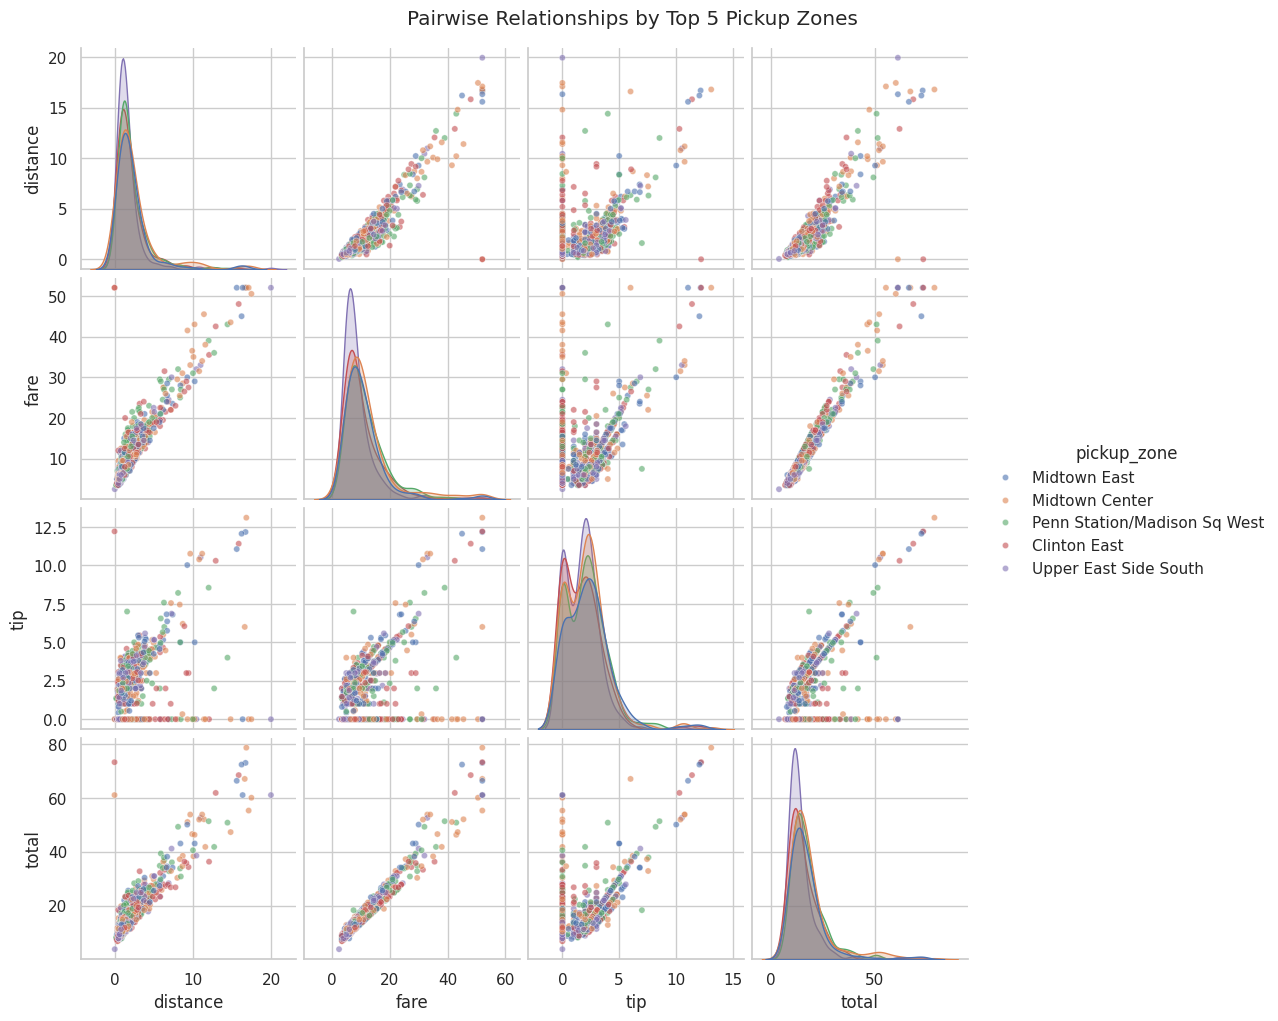

In [12]:
top_zones = df_clean["pickup_zone"].value_counts().head(5).index
pair_df = df_clean[df_clean["pickup_zone"].isin(top_zones)]

g = sns.pairplot(
    pair_df, vars=["distance", "fare", "tip", "total"],
    hue="pickup_zone", diag_kind="kde", plot_kws={"alpha": 0.6, "s": 20}
)
g.figure.suptitle("Pairwise Relationships by Top 5 Pickup Zones", y=1.02)
plt.show()

**Insight:** Distance, fare and total move together in every zone. Zones differ mainly in trip length: Midtown Center averages the longest trips (2.6 miles, $12.48 fare) and Upper East Side South the shortest (1.6 miles, $8.71 fare).

### 4.5 Violin plot - fare by payment method

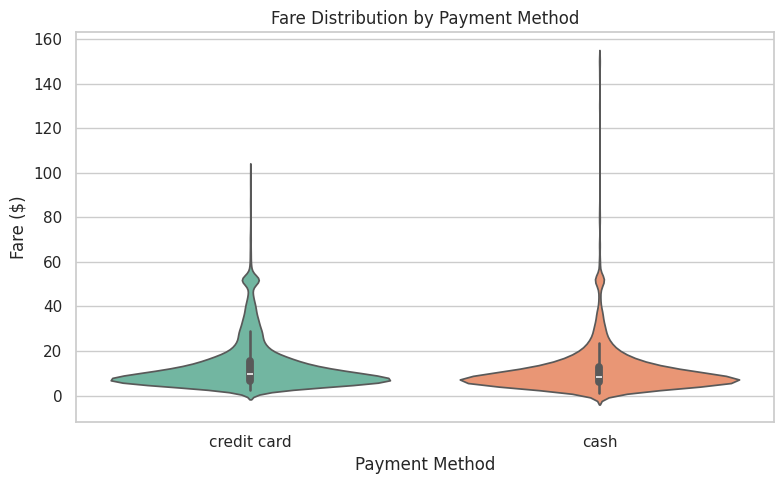

             count   mean  median
payment                          
cash          1807  11.61     8.5
credit card   4600  13.60     9.5


In [13]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_clean, x="payment", y="fare", hue="payment", palette="Set2", inner="box", legend=False)
plt.title("Fare Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare ($)")
plt.tight_layout()
plt.show()

print(df_clean.groupby("payment")["fare"].agg(["count", "mean", "median"]).round(2))

**Insight:** Both payment methods have a similar shape, with most fares at the low end. Credit card trips have a slightly higher average fare ($13.60 vs $11.61) and median ($9.50 vs $8.50).

## 5. Key findings summary

In [14]:
summary = {
    "Rows analysed": len(df_clean),
    "Share of trips starting in Manhattan": f"{(df_clean['pickup_borough'] == 'Manhattan').mean():.1%}",
    "Share paid by credit card": f"{(df_clean['payment'] == 'credit card').mean():.1%}",
    "Median distance (miles)": round(df_clean["distance"].median(), 2),
    "Median fare ($)": round(df_clean["fare"].median(), 2),
    "Average tip ($)": round(df_clean["tip"].mean(), 2),
    "Distance-fare correlation": round(df_clean["distance"].corr(df_clean["fare"]), 3),
}
pd.Series(summary, name="value").to_frame()

,value
Rows analysed,6407
Share of trips starting in Manhattan,82.2%
Share paid by credit card,71.8%
Median distance (miles),1.65
Median fare ($),9.5
Average tip ($),1.97
Distance-fare correlation,0.939
